AIM: To implement a fuzzy logic-based system for grading students based on marks and attendance.

ALGORITHM

1. Define input variables (marks, attendance)
2. Define output variable (grade)
3. Create fuzzy membership functions (low, medium, high)
4. Define fuzzy rules
5. Apply fuzzy inference system
6. Compute output grade
7. Display result
8.   List item



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 19.1 MB/s eta 0:00:00
Grade Score: 8.346153846153847


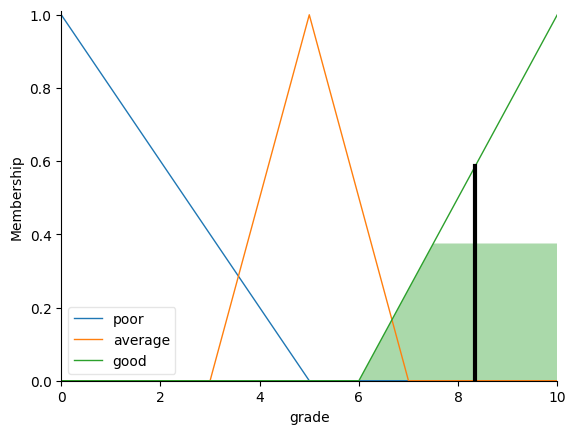

In [ ]:
# Install library
!pip install scikit-fuzzy

# Import libraries
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Define inputs
marks = ctrl.Antecedent(np.arange(0, 101, 1), 'marks')
attendance = ctrl.Antecedent(np.arange(0, 101, 1), 'attendance')

# Define output
grade = ctrl.Consequent(np.arange(0, 11, 1), 'grade')

# Membership functions
marks['low'] = fuzz.trimf(marks.universe, [0, 0, 50])
marks['medium'] = fuzz.trimf(marks.universe, [30, 50, 70])
marks['high'] = fuzz.trimf(marks.universe, [60, 100, 100])

attendance['low'] = fuzz.trimf(attendance.universe, [0, 0, 50])
attendance['medium'] = fuzz.trimf(attendance.universe, [30, 50, 70])
attendance['high'] = fuzz.trimf(attendance.universe, [60, 100, 100])

grade['poor'] = fuzz.trimf(grade.universe, [0, 0, 5])
grade['average'] = fuzz.trimf(grade.universe, [3, 5, 7])
grade['good'] = fuzz.trimf(grade.universe, [6, 10, 10])

# Rules
rule1 = ctrl.Rule(marks['low'] | attendance['low'], grade['poor'])
rule2 = ctrl.Rule(marks['medium'], grade['average'])
rule3 = ctrl.Rule(marks['high'] & attendance['high'], grade['good'])

# Control system
grading_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
grading = ctrl.ControlSystemSimulation(grading_ctrl)

# Input values
grading.input['marks'] = 75
grading.input['attendance'] = 80

# Compute result
grading.compute()

print("Grade Score:", grading.output['grade'])

# Show graph
grade.view(sim=grading)

In [ ]:
# Re-initialize and compute grading system to ensure 'grading' is defined in this scope
# This addresses a NameError if previous cells defining 'grading' were not run or kernel was reset.
# This assumes 'ctrl', 'grading_ctrl', 'rule1', 'rule2', 'rule3', 'marks', 'attendance' are available from previous executions.
import skfuzzy.control as ctrl

grading_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
grading = ctrl.ControlSystemSimulation(grading_ctrl)
grading.input['marks'] = 75
grading.input['attendance'] = 80
grading.compute()

def get_letter_grade(score):
    if score >= 9:
        return 'A'
    elif score >= 8:
        return 'B'
    elif score >= 7:
        return 'C'
    elif score >= 6:
        return 'D'
    else:
        return 'F'

# Get the letter grade for the computed score
letter_grade = get_letter_grade(grading.output['grade'])
print("Letter Grade:", letter_grade)

Letter Grade: B


The fuzzy logic- evaluate student performance= linguistic variables like **low, medium, and high.**